# Graphs Script:

- The following script is used to visualize the graphs created after the iterations:
- The chosen file needs to be entered before executing-> `KEYWORD_TO_FIND`

In [ ]:
# Define the exact file you are looking for
# You can type "Plastic_up", "Rubber_down", "Metal_left", etc.
# Name of material,underscore, direction of swipte 
KEYWORD_TO_FIND = "Plastic_up"

In [ ]:
# Cell 1: Setup & Imports
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# 2. Automatically find the file using os.path
current_dir = os.getcwd()
plots_folder = os.path.join(current_dir, "plots")

# Grab EVERY .npz file in the plots folder first
search_pattern = os.path.join(plots_folder, "*.npz")
all_files = glob.glob(search_pattern)

# 3. Filter the files case-insensitively
found_files = [
    f for f in all_files 
    if KEYWORD_TO_FIND.lower() in os.path.basename(f).lower()
]

if not found_files:
    print(f"Error: Could not find any .npz files containing '{KEYWORD_TO_FIND}' in {plots_folder}")
else:
    # Grab the first file that matches our smart search
    FILE_PATH = found_files[0]
    print(f"Success! Loaded file: {os.path.basename(FILE_PATH)}")

Success! Loaded file: Plastic_up_GLOBAL_DATA.npz


- Loads the collected data
- Calculates the shear and depth velocity
- Arranges the data into interactive graphs for better visualisation

In [ ]:
# 2. Load the raw data
data = np.load(FILE_PATH)
time_arr = data['time']
depth_arr = data['depth']
shear_arr = data['shear']

# Calculate velocities
velocity = np.diff(shear_arr) / np.diff(time_arr)
normal_velocity = np.diff(depth_arr) / np.diff(time_arr)

# Plotting
fig, (ax1, ax2,ax3,ax4) = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

# Subplot 1: Indentation Profile (Left Axis) vs Scaled Shear (Right Twin Axis)
# Using a twin axis prevents the massive integrated shear values from flattening your depth curve!
ax1.plot(time_arr, depth_arr, color='blue', linewidth=2, label="Depth")
ax1.set_ylabel("Depth (px*mm)", color='blue', fontsize=12)
ax1.set_xlabel("Time (s)", fontsize=12)
ax1.set_title("Depth", fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.5)

# === Subplot 2: Isolated Shear Force Profile ===
ax2.plot(time_arr, np.array(shear_arr), color='red', linewidth=2)
ax2.set_title("Shear", fontsize=14)
ax2.set_xlabel("Time (s)", fontsize=12)
ax2.set_ylabel("Shear Displacement (px*mm)", color='red', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5)

#Velocity Profile (Dip Detection)
ax3.plot(time_arr[1:], velocity, color='green')
ax3.set_title("Tangential Velocity", fontsize=14)
ax3.set_xlabel("Time (s)", fontsize=12)
ax3.set_ylabel("Velocity (px*mm/s)", color='green', fontsize=12)
ax3.grid(True, linestyle='--', alpha=0.5)

# Subplot 4: NEW UN-STACKED TANGENTIAL SLIP VELOCITY (FRICTION SLIP ANALYSIS)
# This captures the high-frequency transitions of the hold-and-release pattern directly.
ax4.plot(time_arr[1:], normal_velocity, color='crimson', linewidth=1.5)
ax4.set_title("Depth Velocity ", fontsize=13)
ax4.set_xlabel("Time (s)", fontsize=11)
ax4.set_ylabel("Velocity (px*mm/s)", color='crimson', fontsize=11)
ax4.grid(True, linestyle='--', alpha=0.5)

plt.suptitle(f"Tactile Profile Relationships over Time: {FILE_PATH.split('/')[-1]}", fontsize=14)
plt.tight_layout()

# This will pop open the window WITH the interactive zoom toolbar!
plt.show()

# Neural Network Script:

- The neural network takes the data obtained from the experiments. 
- The final set of data includes sixty iterations of the 2-second swiping motion for each orientation of every material. 

In [4]:
%matplotlib inline
import os
import glob
import torch
import torch.nn as nn
import numpy as np
import datetime
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader



#--- Find Folder ---
current_dir = os.getcwd()
DATASET_FOLDER = os.path.join(current_dir, "Dataset")

# Quick safety check to make sure the path resolved correctly
if not os.path.exists(DATASET_FOLDER):
    print(f"ERROR: Could not find Dataset folder at {DATASET_FOLDER}")
    print("Make sure your Jupyter Notebook is saved in the main COGAR_Assignment_2026 folder!")
else:
    print(f"Success! Loading training data from: {DATASET_FOLDER}")


#--- Create Saved Models Folder ---
model_dir = os.path.join(current_dir, "Saved_Models")

if not os.path.exists(model_dir):
    os.makedirs(model_dir)    


Success! Loading training data from: c:\Users\stefa\OneDrive - unige.it\Univeristy of Genoa\Year 1\Semester 2\CogAR\COGAR assignments-20260326\GIT_Repository_COGAR\COGAR_Assignment_2026\Dataset


- It needs to execute the time-series transformer logic, where it applies weights to data and receives penalties for incorrect presumptions when compared to the actual tensor.
- Loads the data (shear, depth, and their velocities)
- Classifies them accordingly 
- This is a supervised training method with classification.

In [ ]:

# --- 1. THE TIME-SERIES TRANSFORMER ARCHITECTURE ---
class TactileTransformerClassifier(nn.Module):
    def __init__(self, num_features=4, num_classes=3, seq_len=500, d_model=64, nhead=4, num_layers=2):
        super(TactileTransformerClassifier, self).__init__()
        self.input_projection = nn.Linear(num_features, d_model)
        self.positional_embedding = nn.Parameter(torch.zeros(1, seq_len, d_model))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4, dropout=0.1, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.fc_out = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, num_classes)
        )
        
    def forward(self, x):
        x = self.input_projection(x) + self.positional_embedding
        x = self.transformer_encoder(x)
        x = torch.mean(x, dim=1) # Global Average Pooling
        output = self.fc_out(x)
        return output

# --- 2. THE CUSTOM DATASET LOADER ---
class DaimonDataset(Dataset):
    def __init__(self, root_dir):
        """
        Scans the root directory and maps files to labels recursively.
        """
        self.file_paths = []
        self.labels = []
        
        self.class_map = {
            "Rubber": 0,
            "Plastic": 1,
            "Metal": 2
        }
        
        print("Scanning directories for .npy files...")
        search_path = os.path.join(root_dir, "**", "*.npy")
        all_found_files = glob.glob(search_path, recursive=True)
        
        for file_path in all_found_files:
            normalized_path = file_path.replace('\\', '/')
            for material_name, label_idx in self.class_map.items():
                if f"/{material_name}/" in normalized_path or f"{material_name}_" in os.path.basename(normalized_path):
                    self.file_paths.append(file_path)
                    self.labels.append(label_idx)
                    break 
                
        print(f"Dataset Loaded: Found {len(self.file_paths)} total trial files.")

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # 1. Load the pre-processed physics data from the hard drive
        # Since preprocess_experiment_run already calculated velocities, 
        # the shape is exactly 500x4 -> [Depth, Shear, Depth_Velocity, Shear_Velocity]
        file_path = self.file_paths[idx]
        features_matrix = np.load(file_path) 
        
        # 2. NORMALIZATION (Z-Score Standardization)
        # This fixes the "Exploding Gradient" (NaN) error by shrinking the massive numbers!
        for i in range(features_matrix.shape[1]):
            col_mean = np.mean(features_matrix[:, i])
            col_std = np.std(features_matrix[:, i])
            if col_std > 1e-6: 
                features_matrix[:, i] = (features_matrix[:, i] - col_mean) / col_std
            else:
                features_matrix[:, i] = features_matrix[:, i] - col_mean
        
        # 5. Convert to PyTorch Tensors
        label = self.labels[idx]
        tensor_x = torch.tensor(features_matrix, dtype=torch.float32) 
        tensor_y = torch.tensor(label, dtype=torch.long)          
        
        return tensor_x, tensor_y




- Identifies the dataset to use
- Studies the data given 50 times over.
- Trains 74% of the data and tests 16%
- Breaks down its progress as it is training
- Saves the trained model to be used in the live classifier test

In [6]:

# --- Configuration ---
BATCH_SIZE = 16 
EPOCHS = 50
NUM_CLASSES = 3  
NUM_FEATURES = 4 # [Depth, Shear, Depth_Velocity, Shear_Velocity]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# 1. Initialize the Dataset
dataset = DaimonDataset(root_dir=DATASET_FOLDER)

total_samples = len(dataset)
if total_samples == 0:
    print(f"\n[ERROR] Found 0 .npy files inside {DATASET_FOLDER}.")
    print("Ensure your files contain 'Rubber', 'Plastic', or 'Metal' in their names or parent folders.")
    exit()

# --- THE TRAIN / TEST SPLIT ---
train_size = int(total_samples * (50.0 / 60.0)) 
test_size = total_samples - train_size

print(f"[DATA] Total Files Found: {total_samples}")
print(f"\nSplitting Data -> Training on {train_size} files, Testing on {test_size} files.")
    
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 2. Initialize the Model
model = TactileTransformerClassifier(num_features=NUM_FEATURES, num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 3. The Training Loop
print("\nStarting Transformer Training...")

for epoch in range(1, EPOCHS + 1):
    # --- A. TRAINING PHASE ---
    model.train() 
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)
        
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        _, predicted_classes = torch.max(predictions, 1)
        correct_train += (predicted_classes == batch_y).sum().item()
        total_train += batch_y.size(0)
        
    epoch_train_loss = running_train_loss / len(train_loader)
    epoch_train_acc = (correct_train / total_train) * 100

    # --- B. TESTING PHASE ---
    model.eval()  
    running_test_loss = 0.0
    correct_test = 0
    total_test = 0

    all_true_labels = []
    all_model_guesses = []
    
    with torch.no_grad(): 
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)
            
            running_test_loss += loss.item()
            _, predicted_classes = torch.max(predictions, 1)
            correct_test += (predicted_classes == batch_y).sum().item()
            total_test += batch_y.size(0)

            all_model_guesses.extend(predicted_classes.cpu().numpy())
            all_true_labels.extend(batch_y.cpu().numpy())
            
    epoch_test_loss = running_test_loss / len(test_loader)
    epoch_test_acc = (correct_test / total_test) * 100
        
    print(f"Epoch [{epoch:02d}/{EPOCHS}] | Train Acc: {epoch_train_acc:5.1f}% | Test Acc: {epoch_test_acc:5.1f}% (Test Loss: {epoch_test_loss:.4f})")

    # --- Detailed breakdown every 10 epochs ---
    if epoch % 10 == 0 or epoch == EPOCHS:
        print("\n" + "-"*50)
        print(f"DETAILED MATERIAL BREAKDOWN (Epoch {epoch}):")
        target_names = ["Rubber", "Plastic", "Metal"]
        
        report = classification_report(all_true_labels, all_model_guesses, target_names=target_names, zero_division=0)
        print(report)
        print("-"  * 50 + "\n")

# --- 4. SAVING THE MODEL'S MEMORY ---
print("\nTraining Complete.")
    
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
filename = f"daimon_transformer_{timestamp}.pth"
save_path = os.path.join(model_dir, filename)

torch.save(model.state_dict(), save_path)
print(f"[SUCCESS] Model intelligence saved permanently to: {save_path}")
 



Training on device: cuda
Scanning directories for .npy files...
Dataset Loaded: Found 720 total trial files.
[DATA] Total Files Found: 720

Splitting Data -> Training on 600 files, Testing on 120 files.

Starting Transformer Training...
Epoch [01/50] | Train Acc:  39.5% | Test Acc:  66.7% (Test Loss: 0.8753)
Epoch [02/50] | Train Acc:  69.0% | Test Acc:  80.0% (Test Loss: 0.5304)
Epoch [03/50] | Train Acc:  79.8% | Test Acc:  67.5% (Test Loss: 0.8105)
Epoch [04/50] | Train Acc:  82.0% | Test Acc:  81.7% (Test Loss: 0.4590)
Epoch [05/50] | Train Acc:  87.7% | Test Acc:  91.7% (Test Loss: 0.2686)
Epoch [06/50] | Train Acc:  91.8% | Test Acc:  93.3% (Test Loss: 0.1962)
Epoch [07/50] | Train Acc:  88.8% | Test Acc:  90.0% (Test Loss: 0.3531)
Epoch [08/50] | Train Acc:  93.2% | Test Acc:  91.7% (Test Loss: 0.2476)
Epoch [09/50] | Train Acc:  96.5% | Test Acc:  95.8% (Test Loss: 0.1269)
Epoch [10/50] | Train Acc:  98.0% | Test Acc:  96.7% (Test Loss: 0.0891)

--------------------------------

- We can visualise the final classification report to determine whether the collected data was enough to find distinctions between materials.
- We can visualise the confusion matrix which tests whether the trained data was sufficient enough to accurately classify the test data.
- The tested data is selected at random, so varying confusion matrix numbers for each true material against predicted material are expected.


FINAL DETAILED MATERIAL BREAKDOWN:
              precision    recall  f1-score   support

      Rubber       1.00      1.00      1.00        48
     Plastic       1.00      0.97      0.99        39
       Metal       0.97      1.00      0.99        33

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120


Generating final Classification Report table graphic...
[SUCCESS] Publication-ready Report Table saved to: c:\Users\stefa\OneDrive - unige.it\Univeristy of Genoa\Year 1\Semester 2\CogAR\COGAR assignments-20260326\GIT_Repository_COGAR\COGAR_Assignment_2026\Saved_Models\classification_report_20260621_2236.pdf

Generating final Confusion Matrix graphic...
[SUCCESS] Publication-ready Confusion Matrix saved to: c:\Users\stefa\OneDrive - unige.it\Univeristy of Genoa\Year 1\Semester 2\CogAR\COGAR assignments-20260326\GIT_Repository_COGAR\COGAR_Assignment_2026\Saved_Models\confusion_

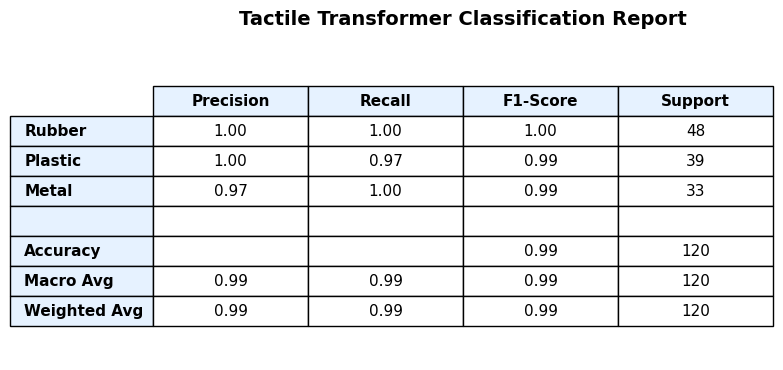

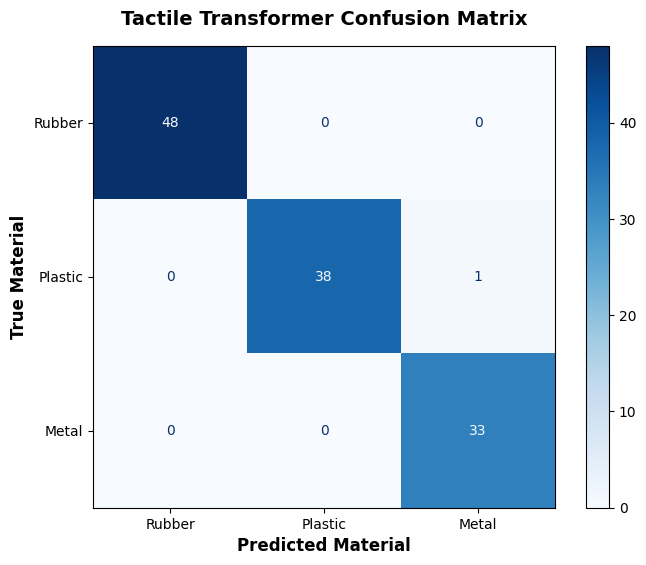

In [7]:
# --- 5. PRINT REPORTS AND GRAPHICS ---
target_names = ["Rubber", "Plastic", "Metal"] 
print("\nFINAL DETAILED MATERIAL BREAKDOWN:")
report = classification_report(all_true_labels, all_model_guesses, target_names=target_names, zero_division=0)
print(report)

# 2. Extract math as a dictionary
report_dict = classification_report(all_true_labels, all_model_guesses, target_names=target_names, zero_division=0, output_dict=True)

# --- NEW: Generate Visual Table Graphic ---
print("\nGenerating final Classification Report table graphic...")
fig_tbl, ax_tbl = plt.subplots(figsize=(8, 4))
ax_tbl.axis('off')
ax_tbl.axis('tight')

row_labels = target_names + ["", "Accuracy", "Macro Avg", "Weighted Avg"]
col_labels = ["Precision", "Recall", "F1-Score", "Support"]
cell_text = []

# Populate material rows
for name in target_names:
    cell_text.append([f"{report_dict[name]['precision']:.2f}", 
                        f"{report_dict[name]['recall']:.2f}", 
                        f"{report_dict[name]['f1-score']:.2f}", 
                        f"{int(report_dict[name]['support'])}"])
    
cell_text.append(["", "", "", ""]) # Empty separator row

# Populate Accuracy and Averages
total_support = int(report_dict['macro avg']['support'])
cell_text.append(["", "", f"{report_dict['accuracy']:.2f}", f"{total_support}"])

for avg in ['macro avg', 'weighted avg']:
    cell_text.append([f"{report_dict[avg]['precision']:.2f}", 
                        f"{report_dict[avg]['recall']:.2f}", 
                        f"{report_dict[avg]['f1-score']:.2f}", 
                        f"{int(report_dict[avg]['support'])}"])
    
# Draw table
table = ax_tbl.table(cellText=cell_text, rowLabels=row_labels, colLabels=col_labels, loc='center', cellLoc='center')
table.scale(1, 1.8) # Adjust row heights for readability
table.set_fontsize(11)

# Style the headers (Bold font, light blue background)
for (row, col), cell in table.get_celld().items():
    if row == 0 or col == -1:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#e6f2ff')
        
plt.title("Tactile Transformer Classification Report", fontsize=14, fontweight='bold', pad=20)

# Save as PDF
tbl_filename = os.path.join(model_dir, f"classification_report_{timestamp}.pdf")
plt.savefig(tbl_filename, format='pdf', dpi=300, bbox_inches='tight')
print(f"[SUCCESS] Publication-ready Report Table saved to: {tbl_filename}")

# --- Existing Confusion Matrix Code ---
print("\nGenerating final Confusion Matrix graphic...")
    
cm = confusion_matrix(all_true_labels, all_model_guesses)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title("Tactile Transformer Confusion Matrix", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Predicted Material", fontsize=12, fontweight='bold')
plt.ylabel("True Material", fontsize=12, fontweight='bold')

cm_filename = os.path.join(model_dir, f"confusion_matrix_{timestamp}.pdf")
plt.savefig(cm_filename, format='pdf', dpi=300, bbox_inches='tight')
print(f"[SUCCESS] Publication-ready Confusion Matrix saved to: {cm_filename}")

plt.show()

The live classifier is tested in real-time. This requires access to the Daimon sensor, which requires the packages predefined in the `README` as well as a NVIDIA graphics card